<a href="https://colab.research.google.com/github/handeunaldi/dsa-210-project/blob/main/eda_hypothesis_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Economic Development and Health Outcomes  
## GDP, Healthcare Spending, and Life Expectancy

This project analyzes how GDP per capita and healthcare expenditure affect life expectancy across countries.

### Research Questions
- Does higher GDP increase healthcare spending?
- Does higher GDP increase life expectancy?
- Does higher healthcare spending increase life expectancy?

In [ ]:
# ============================================================
# 1. Setup and data loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind, spearmanr
import statsmodels.api as sm
from pathlib import Path

# Style of the plot
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Figure folder (optional)
PROJECT_ROOT = Path("/content")
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load datasets
life = pd.read_csv("/content/life-expectancy.csv")
health = pd.read_csv("/content/annual-healthcare-expenditure-per-capita.csv")
gdp = pd.read_csv("/content/gdp-per-capita-worldbank.csv")

print("Life expectancy shape:", life.shape)
print("Health expenditure shape:", health.shape)
print("GDP shape:", gdp.shape)

display(life.head())
display(health.head())
display(gdp.head())

Life expectancy shape: (21565, 4)
Health expenditure shape: (4869, 4)
GDP shape: (7240, 5)


,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,28.1563
1,Afghanistan,AFG,1951,28.5836
2,Afghanistan,AFG,1952,29.0138
3,Afghanistan,AFG,1953,29.4521
4,Afghanistan,AFG,1954,29.6975


,Entity,Code,Year,"Current health expenditure per capita, PPP (current international $)"
0,Afghanistan,AFG,2002,85.857500
1,Afghanistan,AFG,2003,85.933020
2,Afghanistan,AFG,2004,93.935810
3,Afghanistan,AFG,2005,105.927704
4,Afghanistan,AFG,2006,118.405820


,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


## 2. Data cleaning and preparation

In this section, the three datasets are cleaned and standardised. Column names are renamed for readability, only the relevant variables are kept, and the datasets are merged using country, country code, and year.

The sample is restricted to years where all three datasets overlap.

In [ ]:
# ============================================================
# 2. Data cleaning and preparation
# ============================================================

# Rename columns
life = life.rename(columns={
    "Entity": "Country",
    "Code": "Code",
    "Year": "Year",
    "Life expectancy": "LifeExpectancy"
})

health = health.rename(columns={
    "Entity": "Country",
    "Code": "Code",
    "Year": "Year",
    "Current health expenditure per capita, PPP (current international $)": "HealthExpPerCapita"
})

gdp = gdp.rename(columns={
    "Entity": "Country",
    "Code": "Code",
    "Year": "Year",
    "GDP per capita": "GDPPerCapita",
    "World region according to OWID": "Region"
})

# Keep only needed columns
life = life[["Country", "Code", "Year", "LifeExpectancy"]]
health = health[["Country", "Code", "Year", "HealthExpPerCapita"]]
gdp = gdp[["Country", "Code", "Year", "GDPPerCapita", "Region"]]

# Merge datasets
df = life.merge(gdp, on=["Country", "Code", "Year"], how="inner")
df = df.merge(health, on=["Country", "Code", "Year"], how="inner")

# Keep valid country codes only
df = df[df["Code"].notna()]
df = df[df["Code"].str.len() == 3]

# Convert numeric columns
numeric_cols = ["LifeExpectancy", "GDPPerCapita", "HealthExpPerCapita"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing values
df = df.dropna(subset=numeric_cols)

# Restrict years to overlap period
df = df[df["Year"] >= 2002]

print("Final merged shape:", df.shape)
display(df.head())

Final merged shape: (4043, 7)


,Country,Code,Year,LifeExpectancy,GDPPerCapita,Region,HealthExpPerCapita
0,Afghanistan,AFG,2002,56.2251,1774.3087,Asia,85.857500
1,Afghanistan,AFG,2003,57.1713,1815.9282,Asia,85.933020
2,Afghanistan,AFG,2004,57.8098,1776.9182,Asia,93.935810
3,Afghanistan,AFG,2005,58.2468,1908.1147,Asia,105.927704
4,Afghanistan,AFG,2006,58.5533,1929.7239,Asia,118.405820


## 3. Descriptive statistics and sanity checks

We check the basic structure of the final merged dataset before moving to the visual analysis:

- number of observations  
- number of unique countries  
- year range  
- missing values  
- summary statistics  

This confirms that the merge and cleaning steps worked correctly.

In [ ]:
# ============================================================
# 3. Descriptive statistics and sanity checks
# ============================================================

print("Number of observations:", len(df))
print("Number of unique countries:", df["Country"].nunique())
print("Year range:", df["Year"].min(), "-", df["Year"].max())

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df[["Year", "LifeExpectancy", "GDPPerCapita", "HealthExpPerCapita"]].describe())

Number of observations: 4043
Number of unique countries: 186
Year range: 2002 - 2023

Missing values by column:
Country               0
Code                  0
Year                  0
LifeExpectancy        0
GDPPerCapita          0
Region                0
HealthExpPerCapita    0
dtype: int64

Summary statistics:


,Year,LifeExpectancy,GDPPerCapita,HealthExpPerCapita
count,4043.000000,4043.000000,4043.000000,4043.000000
mean,2012.545387,70.456136,22179.608461,1285.137700
std,6.331445,8.559314,23715.462384,1668.930732
min,2002.000000,14.665500,795.772160,10.528234
25%,2007.000000,64.926500,4969.267100,188.068770
50%,2013.000000,71.706900,13586.516000,615.814450
75%,2018.000000,76.776000,31498.880500,1662.828650
max,2023.000000,85.708200,145590.770000,13473.193000


## 4. Exploratory Data Analysis (EDA)

GDP per capita, healthcare expenditure, and life expectancy are explored in this section through visual analysis.

The goal is not to formally test the hypotheses yet, but to build intuition by examining patterns in the data.

The hypotheses are explored visually as follows:

- **H1:** GDP per capita is associated with healthcare expenditure  
- **H2:** GDP per capita is associated with life expectancy  
- **H3:** Healthcare expenditure is associated with life expectancy  

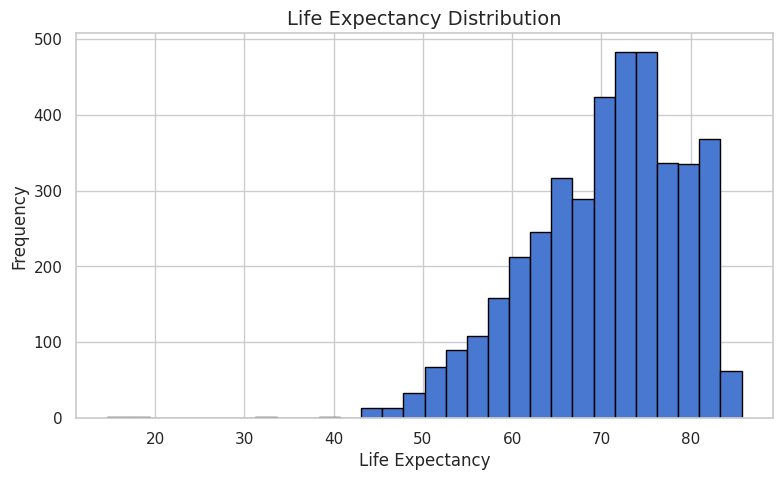

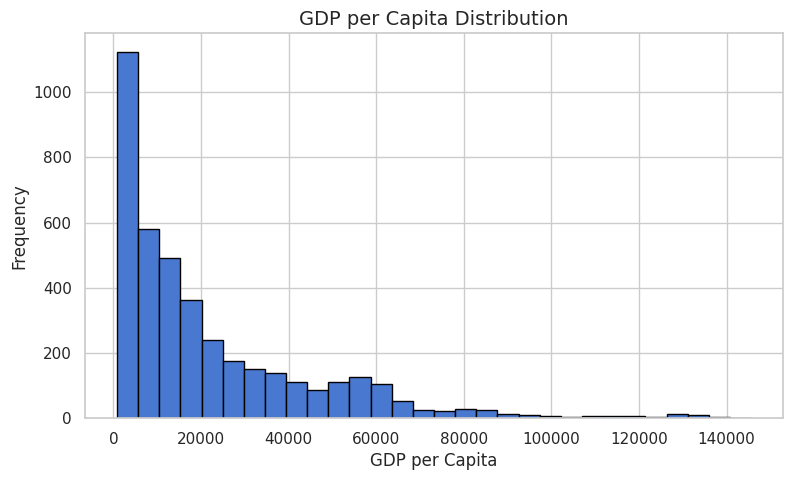

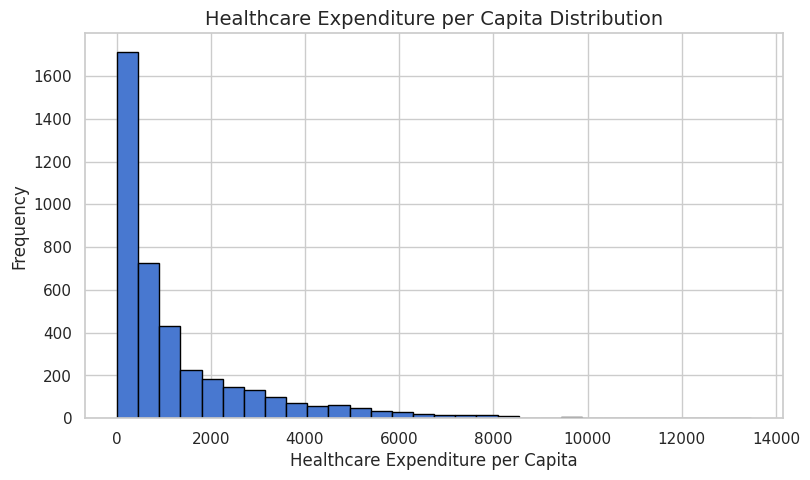

In [ ]:
# ============================================================
# 4.1 Distributions
# ============================================================

plt.hist(df["LifeExpectancy"], bins=30, edgecolor="black")
plt.title("Life Expectancy Distribution")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "life_expectancy_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.hist(df["GDPPerCapita"], bins=30, edgecolor="black")
plt.title("GDP per Capita Distribution")
plt.xlabel("GDP per Capita")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "gdp_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.hist(df["HealthExpPerCapita"], bins=30, edgecolor="black")
plt.title("Healthcare Expenditure per Capita Distribution")
plt.xlabel("Healthcare Expenditure per Capita")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "health_exp_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

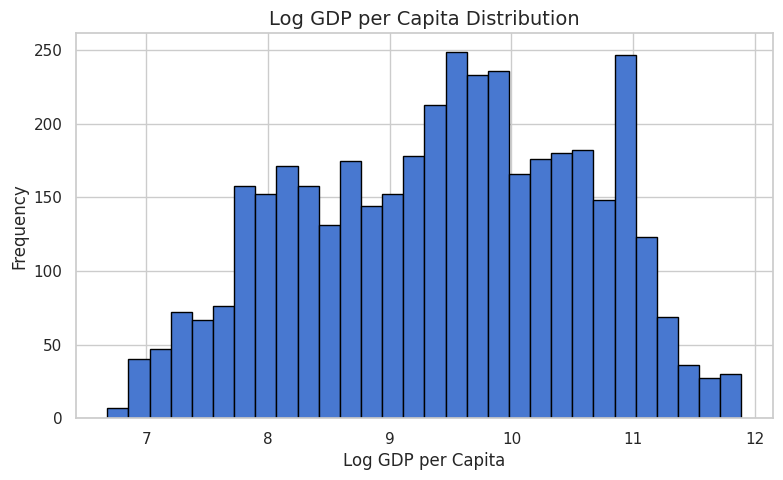

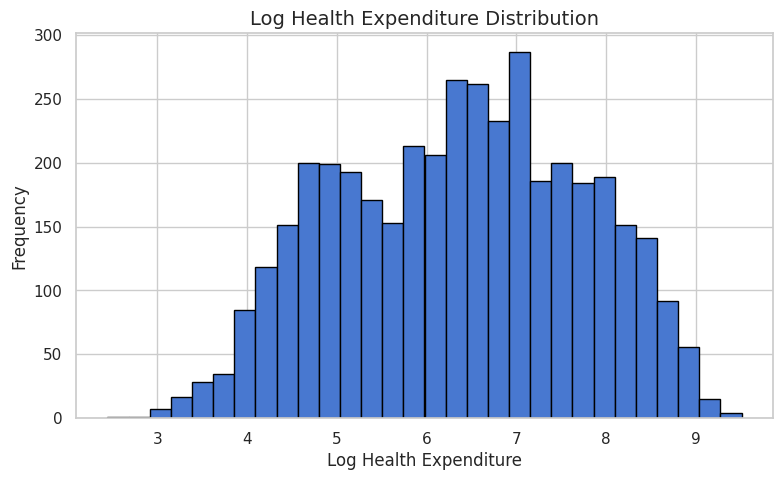

In [ ]:
# ============================================================
# 4.2 Log transformation
# ============================================================

df["LogGDP"] = np.log(df["GDPPerCapita"] + 1)
df["LogHealth"] = np.log(df["HealthExpPerCapita"] + 1)

plt.hist(df["LogGDP"], bins=30, edgecolor="black")
plt.title("Log GDP per Capita Distribution")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "log_gdp_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.hist(df["LogHealth"], bins=30, edgecolor="black")
plt.title("Log Health Expenditure Distribution")
plt.xlabel("Log Health Expenditure")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "log_health_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

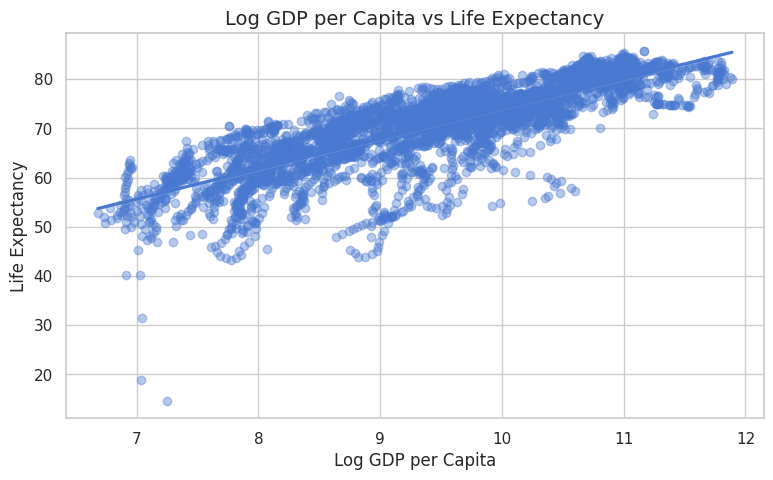

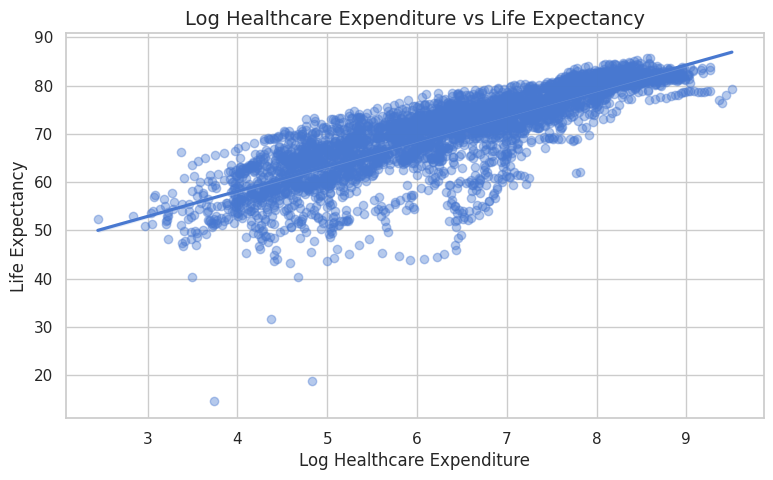

In [ ]:
# ============================================================
# 4.3 Scatter plots
# ============================================================

sns.regplot(data=df, x="LogGDP", y="LifeExpectancy", scatter_kws={"alpha": 0.4})
plt.title("Log GDP per Capita vs Life Expectancy")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Expectancy")
plt.savefig(FIG_DIR / "log_gdp_vs_life.png", dpi=300, bbox_inches="tight")
plt.show()

sns.regplot(data=df, x="LogHealth", y="LifeExpectancy", scatter_kws={"alpha": 0.4})
plt.title("Log Healthcare Expenditure vs Life Expectancy")
plt.xlabel("Log Healthcare Expenditure")
plt.ylabel("Life Expectancy")
plt.savefig(FIG_DIR / "log_health_vs_life.png", dpi=300, bbox_inches="tight")
plt.show()

,LifeExpectancy,GDPPerCapita,HealthExpPerCapita
Region,,,
Europe,78.129604,44161.853881,2985.153114
South America,73.056524,17536.560613,1025.630278
North America,73.012870,21152.656500,1376.331304
Asia,72.606770,24072.058546,975.253836
Oceania,68.881048,12387.267008,950.109308
Africa,60.978971,6579.126218,271.245127


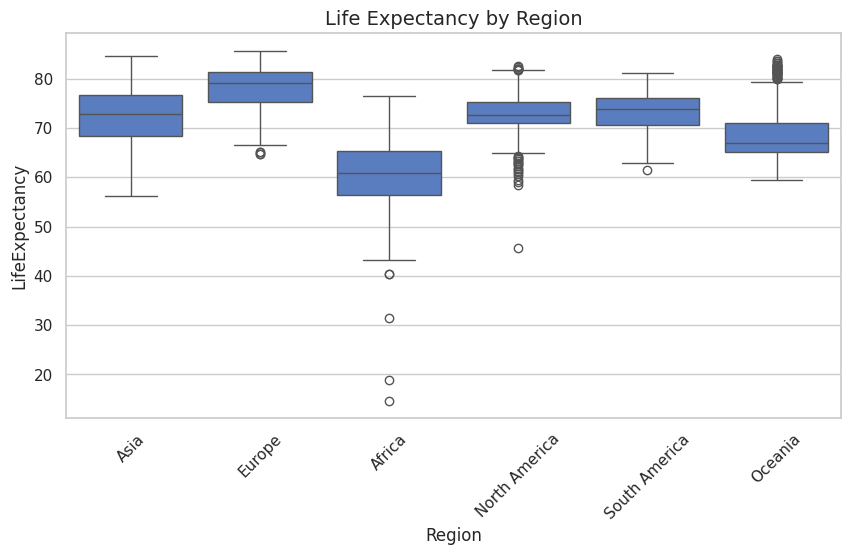

In [ ]:
# ============================================================
# 4.5 Regional comparison
# ============================================================

region_summary = (
    df.groupby("Region")[["LifeExpectancy", "GDPPerCapita", "HealthExpPerCapita"]]
    .mean()
    .sort_values("LifeExpectancy", ascending=False)
)

display(region_summary)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Region", y="LifeExpectancy")
plt.xticks(rotation=45)
plt.title("Life Expectancy by Region")
plt.savefig(FIG_DIR / "life_expectancy_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

### H1: GDP per capita and healthcare expenditure

We expect countries with higher GDP per capita to spend more on healthcare. This relationship reflects the idea that wealthier countries have more resources to invest in public health systems.

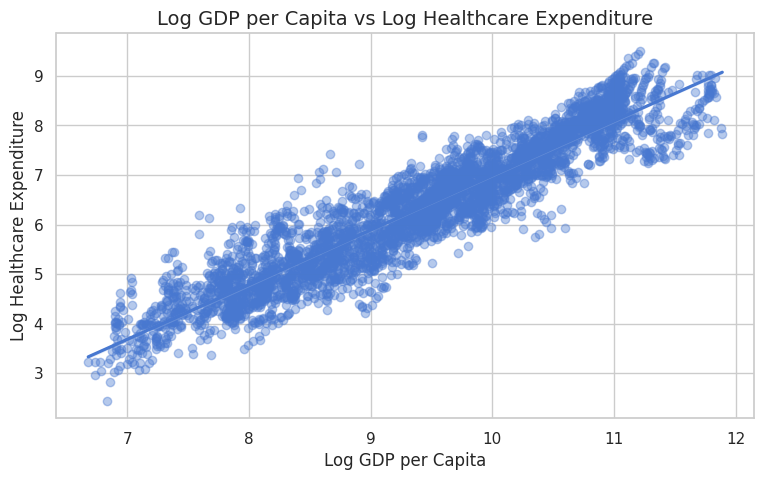

In [ ]:
sns.regplot(data=df, x="LogGDP", y="LogHealth", scatter_kws={"alpha":0.4})

plt.title("Log GDP per Capita vs Log Healthcare Expenditure")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Log Healthcare Expenditure")

plt.savefig(FIG_DIR / "h1_gdp_vs_health.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**  
The plot shows a strong positive relationship between GDP and healthcare expenditure. Countries with higher income levels tend to allocate more resources to healthcare.

### H2: GDP per capita and life expectancy

Economic theory suggests that higher income levels improve living conditions, nutrition, and access to healthcare, which in turn increase life expectancy.

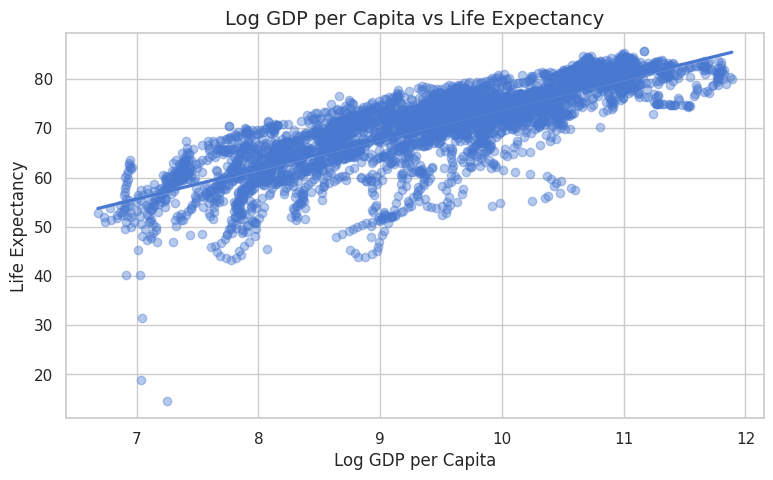

In [ ]:
sns.regplot(data=df, x="LogGDP", y="LifeExpectancy", scatter_kws={"alpha":0.4})

plt.title("Log GDP per Capita vs Life Expectancy")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Expectancy")

plt.savefig(FIG_DIR / "h2_gdp_vs_life.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**  
There is a clear upward trend, indicating that countries with higher GDP per capita tend to have longer life expectancy.

### H3: Healthcare expenditure and life expectancy

Higher healthcare spending is expected to improve health outcomes by increasing access to medical services and improving quality of care.

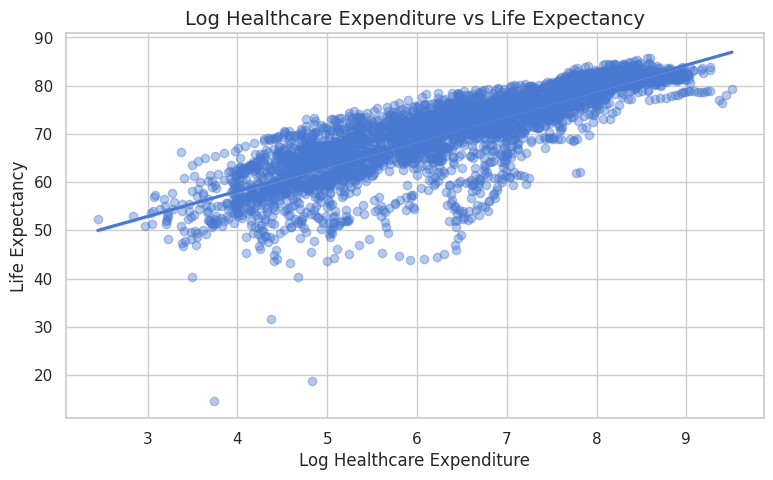

In [ ]:
sns.regplot(data=df, x="LogHealth", y="LifeExpectancy", scatter_kws={"alpha":0.4})

plt.title("Log Healthcare Expenditure vs Life Expectancy")
plt.xlabel("Log Healthcare Expenditure")
plt.ylabel("Life Expectancy")

plt.savefig(FIG_DIR / "h3_health_vs_life.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**  
The relationship appears strongly positive, suggesting that higher healthcare investment is associated with longer life expectancy.

,LifeExpectancy,LogGDP,LogHealth
LifeExpectancy,1.000000,0.823381,0.831385
LogGDP,0.823381,1.000000,0.937367
LogHealth,0.831385,0.937367,1.000000


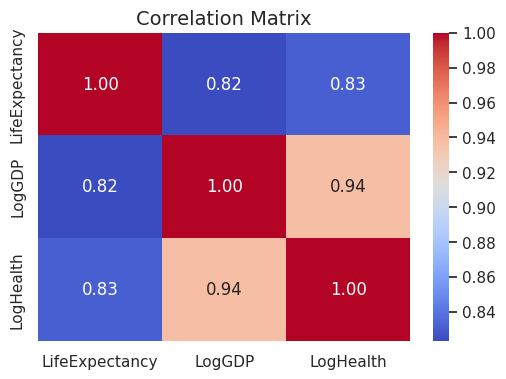

In [ ]:
# ============================================================
# 4.4 Correlation matrix
# ============================================================

corr = df[["LifeExpectancy", "LogGDP", "LogHealth"]].corr()
display(corr)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig(FIG_DIR / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Hypothesis Testing

While the EDA section provided visual intuition about the relationships between variables, this section formally tests the hypotheses using statistical methods.

We use:

- Pearson correlation (linear relationship)
- Spearman correlation (robustness check)
- Group comparison (t-tests)
- Regression analysis

The hypotheses are:

- **H1:** GDP per capita is positively associated with healthcare expenditure  
- **H2:** GDP per capita is positively associated with life expectancy  
- **H3:** Healthcare expenditure is positively associated with life expectancy  

In [ ]:
# ============================================================
# H1: GDP vs Healthcare Expenditure
# ============================================================

from scipy.stats import pearsonr, spearmanr

df_h1 = df.dropna(subset=["LogGDP", "LogHealth"])

r_h1, p_h1 = pearsonr(df_h1["LogGDP"], df_h1["LogHealth"])
rho_h1, sp_h1 = spearmanr(df_h1["LogGDP"], df_h1["LogHealth"])

print("H1 – GDP vs Health Expenditure")
print(f"Pearson r = {r_h1:.3f}, p = {p_h1:.4e}")
print(f"Spearman rho = {rho_h1:.3f}, p = {sp_h1:.4e}")

H1 – GDP vs Health Expenditure
Pearson r = 0.937, p = 0.0000e+00
Spearman rho = 0.943, p = 0.0000e+00


**Interpretation:**

There is a strong positive and statistically significant relationship between GDP per capita and healthcare expenditure. This suggests that wealthier countries tend to invest more in healthcare.

In [ ]:
# ============================================================
# H2: GDP vs Life Expectancy
# ============================================================

df_h2 = df.dropna(subset=["LogGDP", "LifeExpectancy"])

r_h2, p_h2 = pearsonr(df_h2["LogGDP"], df_h2["LifeExpectancy"])

print("H2 – GDP vs Life Expectancy")
print(f"Pearson r = {r_h2:.3f}, p = {p_h2:.4e}")

H2 – GDP vs Life Expectancy
Pearson r = 0.823, p = 0.0000e+00


In [ ]:
median_gdp = df_h2["GDPPerCapita"].median()

low_gdp = df_h2[df_h2["GDPPerCapita"] < median_gdp]["LifeExpectancy"]
high_gdp = df_h2[df_h2["GDPPerCapita"] >= median_gdp]["LifeExpectancy"]

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(high_gdp, low_gdp, equal_var=False)

print("\nT-test (High vs Low GDP)")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_val:.4f}")
print(f"Low GDP mean  = {low_gdp.mean():.2f}")
print(f"High GDP mean = {high_gdp.mean():.2f}")


T-test (High vs Low GDP)
t-statistic = 59.952
p-value     = 0.0000
Low GDP mean  = 64.58
High GDP mean = 76.33


**Interpretation:**

The results show that countries with higher GDP per capita have significantly higher life expectancy. Both correlation and group comparison strongly support the hypothesis.

In [ ]:
# ============================================================
# H3: Healthcare Expenditure vs Life Expectancy
# ============================================================

df_h3 = df.dropna(subset=["LogHealth", "LifeExpectancy"])

r_h3, p_h3 = pearsonr(df_h3["LogHealth"], df_h3["LifeExpectancy"])

print("H3 – Health Spending vs Life Expectancy")
print(f"Pearson r = {r_h3:.3f}, p = {p_h3:.4e}")

H3 – Health Spending vs Life Expectancy
Pearson r = 0.831, p = 0.0000e+00


In [ ]:
median_health = df_h3["HealthExpPerCapita"].median()

low_h = df_h3[df_h3["HealthExpPerCapita"] < median_health]["LifeExpectancy"]
high_h = df_h3[df_h3["HealthExpPerCapita"] >= median_health]["LifeExpectancy"]

t_stat_h, p_val_h = ttest_ind(high_h, low_h, equal_var=False)

print("\nT-test (High vs Low Health Spending)")
print(f"t-statistic = {t_stat_h:.3f}")
print(f"p-value     = {p_val_h:.4f}")
print(f"Low Health mean  = {low_h.mean():.2f}")
print(f"High Health mean = {high_h.mean():.2f}")


T-test (High vs Low Health Spending)
t-statistic = 58.010
p-value     = 0.0000
Low Health mean  = 64.69
High Health mean = 76.22


**Interpretation:**

Healthcare expenditure is strongly and positively associated with life expectancy. Countries that spend more on healthcare tend to achieve better health outcomes.